In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit import cost

In [2]:
df = pd.read_csv('Exam_Prob1.txt', sep=' ', header=None, names=['x1', 'x2', 'x3', 'x4', 'x5'])
df

,x1,x2,x3,x4,x5
0,22.967736,0.650901,6.0,1.424153,2.000220
1,22.911614,-0.555938,6.0,1.098739,1.801862
2,25.592736,-0.568092,4.0,1.538478,3.456930
3,21.049999,0.491788,1.0,2.130764,1.133346
4,22.811377,-0.911998,5.0,2.028838,5.813735
...,...,...,...,...,...
4995,25.871527,0.617013,5.0,2.160424,3.131517
4996,20.378633,0.541065,5.0,2.437236,1.331026
4997,25.074716,0.843433,1.0,0.906957,8.388173
4998,23.113650,-0.607325,3.0,1.195689,1.409936


In [3]:
x1 = df['x1'].values
x2 = df['x2'].values
x3 = df['x3'].values

In [4]:
def f1(x, a):
    return 1/(x+5)*np.sin(a*x)

def f2(x, a):
    return np.sin(a*x)+1

def f3(x, a):
    return np.sin(a*x**2)

def f4(x, a):
    return (np.sin(a*x+1))**2

def f5(x):
    return x*np.tan(x)

def f6(x, a, b):
    return 1 + a*x + b*(x**2)

def f7(x, a, b):
    return a + b*x

def f8(x, mu, sigma):
    return np.exp(-(x-mu)**2/(2*sigma**2))

def f9(x, a, b, c):
    return np.sin(a*x) + c*np.exp(b*x) + 1

from scipy.stats import binom, poisson, logser

def f10(k, n, p):
    return binom.pmf(k, n, p)

def f11(k, lamb):
    return poisson.pmf(k, lamb)

def f12(k, p):
    return logser.pmf(k, p)

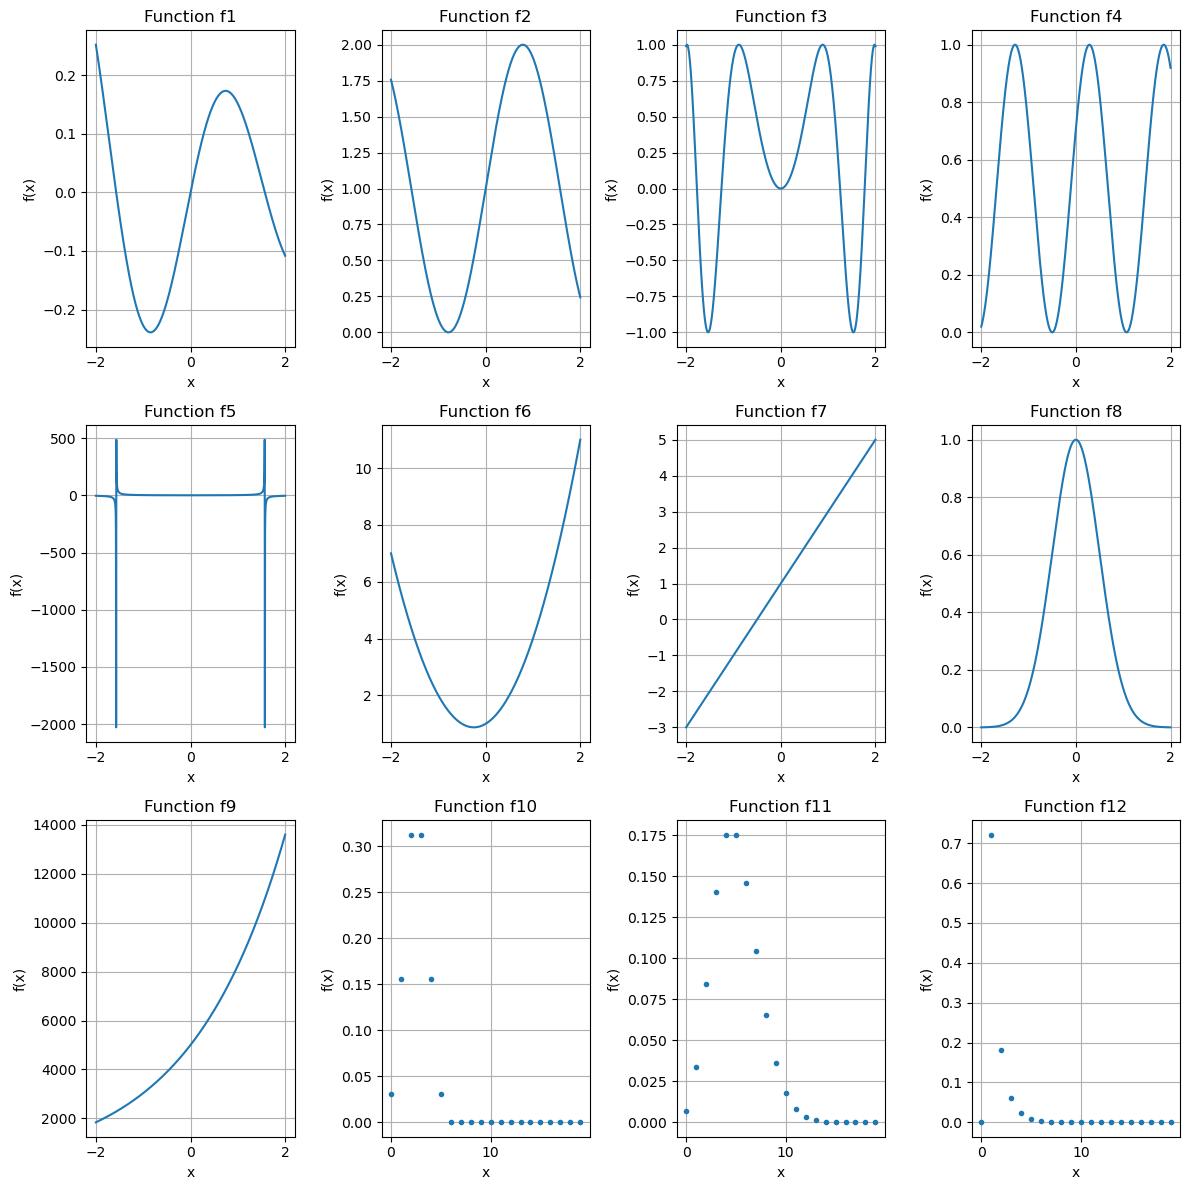

In [8]:
xxCont = np.linspace(-2, 2, 1000)
xxDisc = np.arange(0, 20)
configs = [
    (f1, xxCont, (2,), '-'),
    (f2, xxCont, (2,), '-'),
    (f3, xxCont, (2,), '-'),
    (f4, xxCont, (2,), '-'),
    (f5, xxCont, (), '-'),
    (f6, xxCont, (1, 2), '-'),
    (f7, xxCont, (1, 2), '-'),
    (f8, xxCont, (0, 0.5), '-'),
    (f9, xxCont, (0, 0.5, 5000), '-'),
    (f10, xxDisc, (5, 0.5), '.'),
    (f11, xxDisc, (5,), '.'),
    (f12, xxDisc, (0.5,), '.'),
]

fig, ax = plt.subplots(3, 4, figsize=(12, 12))
ax = ax.flatten()

for i, (f, x, args, style) in enumerate(configs):
    y = f(x, *args)
    ax[i].plot(x, y, style)
    ax[i].set_title(f'Function f{i+1}')
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('f(x)')
    ax[i].grid()


plt.tight_layout()

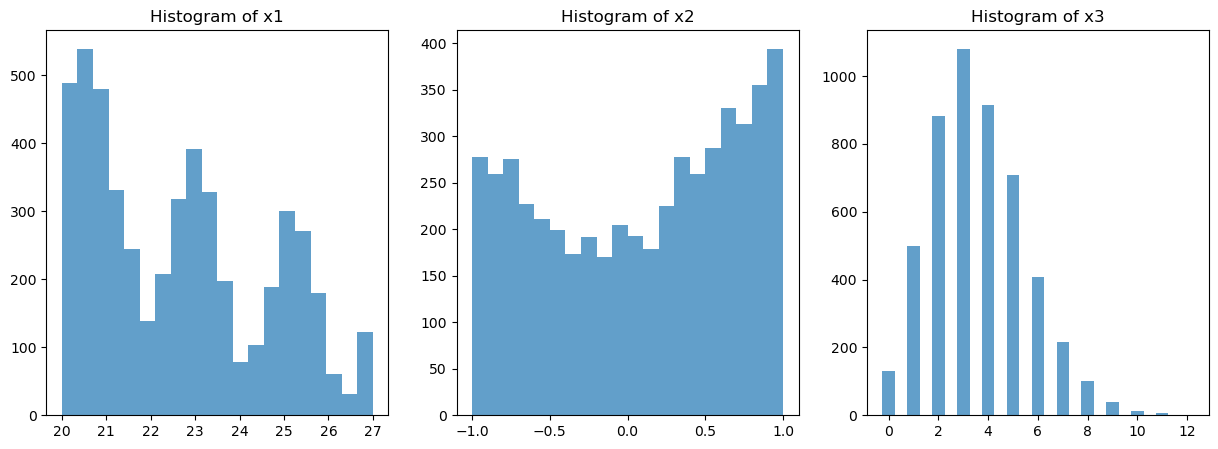

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].hist(x1, bins=20, alpha=0.7)
ax[0].set_title('Histogram of x1')

ax[1].hist(x2, bins=20, alpha=0.7)
ax[1].set_title('Histogram of x2')

x3 = np.array(x3, dtype=int).flatten()

ax[2].bar(np.unique(x3), np.bincount(x3), width=0.5, alpha=0.7)
ax[2].set_title('Histogram of x3');

In [9]:
def raster_scan(cost_func, param_ranges, num_points=100):
    param_names = list(param_ranges.keys())
    n_params = len(param_names)

    grids = [np.linspace(*param_ranges[name], num_points) for name in param_names]

    # 1D scan
    if n_params == 1:
        values = np.array([cost_func(v) for v in grids[0]])/2

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(grids[0], values, color='steelblue')
        ax.set_xlabel(param_names[0])
        ax.set_ylabel('Cost function value')
        ax.set_title(f'Raster Scan — {param_names[0]}')

        best_idx = np.nanargmin(values)         
        best_x   = grids[0][best_idx]
        best_val = values[best_idx]
        ax.axvline(best_x, color='red', ls='--',label=f'Scan min: {param_names[0]} = {best_x:.3f} (NLL={best_val:.2f})')
        ax.legend();

    # 2D scan 
    if n_params == 2:
        g0, g1 = np.meshgrid(grids[0], grids[1])
        points  = np.vstack([g0.ravel(), g1.ravel()]).T
        values  = np.array([cost_func(p[0], p[1]) for p in points]).reshape(g0.shape)/2

        fig, ax = plt.subplots(figsize=(8, 6))
        pcm = ax.pcolormesh(g0, g1, values, cmap='plasma', shading='auto')
        plt.colorbar(pcm, ax=ax, label='Cost function value')

        flat_idx  = np.nanargmin(values)                         
        best_idx  = np.unravel_index(flat_idx, values.shape)      
        best_x    = g0[best_idx]
        best_y    = g1[best_idx]
        best_val  = values[best_idx]
        ax.plot(best_x, best_y, 'r*', ms=14, label=f'Scan min: ({best_x:.3f}, {best_y:.3f})  NLL={best_val:.2f}')
        ax.set_xlabel(param_names[0])
        ax.set_ylabel(param_names[1])
        ax.set_title('Raster Scan — ' + ' vs '.join(np.flipud(param_names)))
        ax.legend();

In [31]:
from scipy.integrate import quad

def f9_norm(x, a, b , c):
    N1 = quad(lambda x: f9(x, a, b, c), 20, 27)
    return f9(x, a, b, c)/N1[0]

In [42]:
def f9_norm_fixed(x, b, c):
    return f9_norm(x, -2.6, b, c)

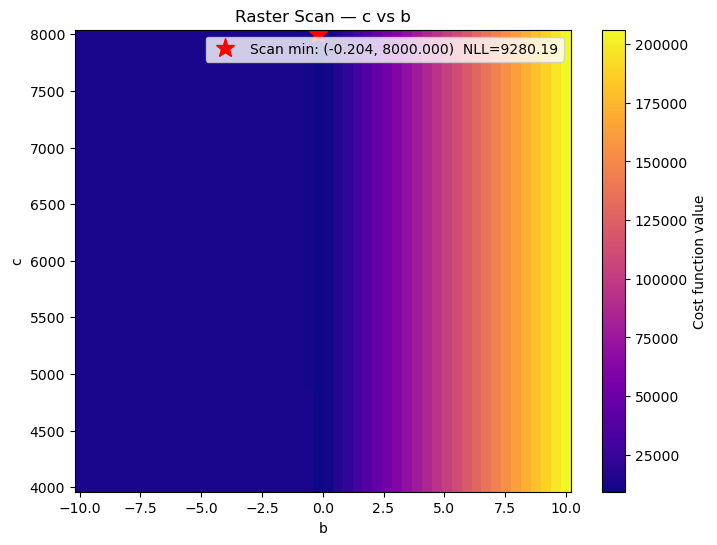

In [43]:
c1 = cost.UnbinnedNLL(x1, f9_norm_fixed)
raster_scan(c1, {'b': (-10,10), 'c': (4000, 8000)}, num_points=50);

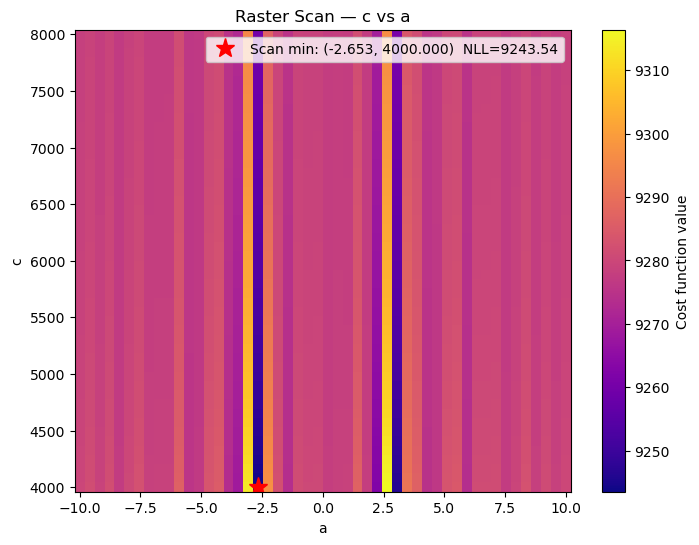

In [44]:
def f9_norm_fixed(x, a, c):
    return f9_norm(x, a, -0.204, c)
c1 = cost.UnbinnedNLL(x1, f9_norm_fixed)
raster_scan(c1, {'a': (-10,10), 'c': (4000, 8000)}, num_points=50);

In [46]:
c1 = cost.UnbinnedNLL(x1, f9_norm)

In [47]:
m1 = Minuit(c1, a=-2.653, b= -0.204, c=5000)

m1.limits['a'] = (-10, 10)
m1.limits['b'] = (-10, 10)
m1.limits['c'] = (4000, 8000)
m1.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.773e+04                  │              Nfcn = 95               │
│ EDM = 7.33e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │  -2.6716  │  0.0013   │            │            │   -10   │   10    │       │
│ 1 │ b    │  -0.371   │   0.004   │            │            │   -10   │   10    │       │
│ 2 │ c    │    4e3    │    4e3    │            │            │  4000   │  8000   │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │  1.66e-06   -0.1e-6  385.3e-6 │
│ b │   -0.1e-6  1.54e-05 56.831e-3 │
│ c │  385.3e-6 56.831e-3       550 │
└───┴───────────────────────────────┘

In [48]:
def f6_norm(x, a, b):
    Z = (2/3) * b + 2
    return (1 + a*x + b*(x**2)) / Z

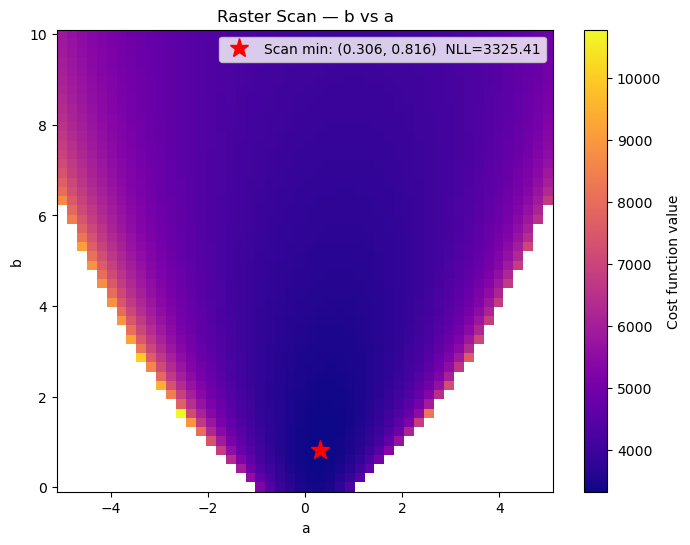

In [51]:
c2 = cost.UnbinnedNLL(x2, f6_norm)
raster_scan(c2, {'a': (-5,5), 'b': (0, 10)}, num_points=50);

In [52]:
m2 = Minuit(c2, a=0.3, b=0.8)
m2.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6650                       │              Nfcn = 31               │
│ EDM = 2.06e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.321   │   0.035   │            │            │         │         │       │
│ 1 │ b    │   0.88    │   0.08    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────┐
│   │       a       b │
├───┼─────────────────┤
│ a │ 0.00122  0.0008 │
│ b │  0.0008 0.00669 │
└───┴─────────────────┘

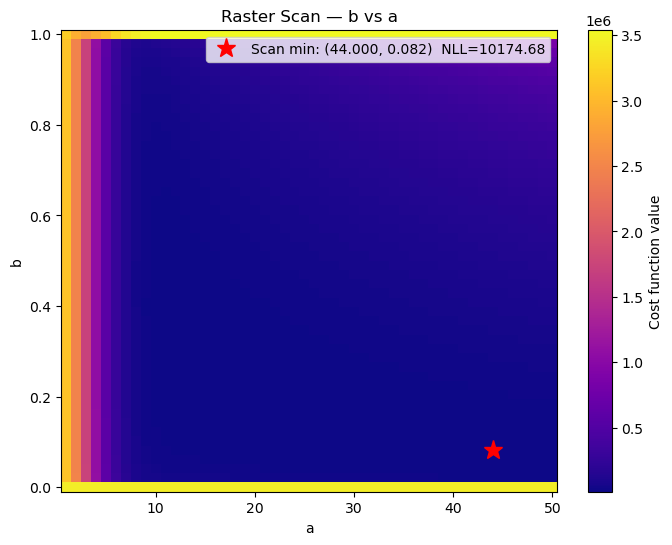

In [60]:
c3 = cost.UnbinnedNLL(x3, f10)
raster_scan(c3, {'a': (1,50), 'b': (0, 1) }, num_points=50);

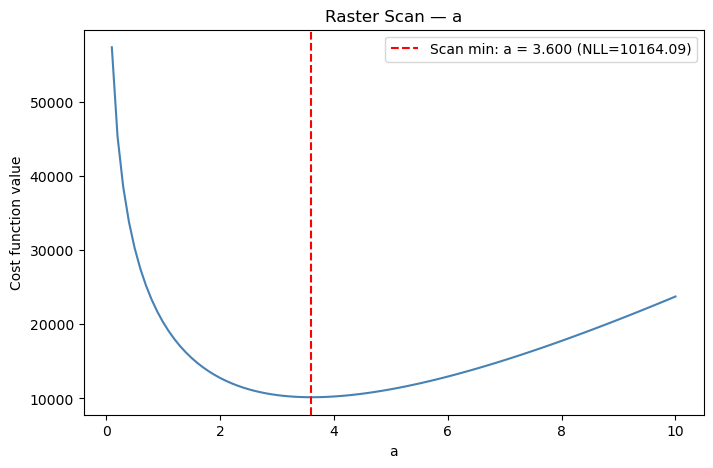

In [53]:
c3 = cost.UnbinnedNLL(x3, f11)
raster_scan(c3, {'a': (0.1,10)}, num_points=100);

In [54]:
m3 = Minuit(c3, lamb=3)
m3.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.033e+04                  │              Nfcn = 19               │
│ EDM = 1.43e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ lamb │   3.608   │   0.027   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────┬──────────┐
│      │     lamb │
├──────┼──────────┤
│ lamb │ 0.000722 │
└──────┴──────────┘

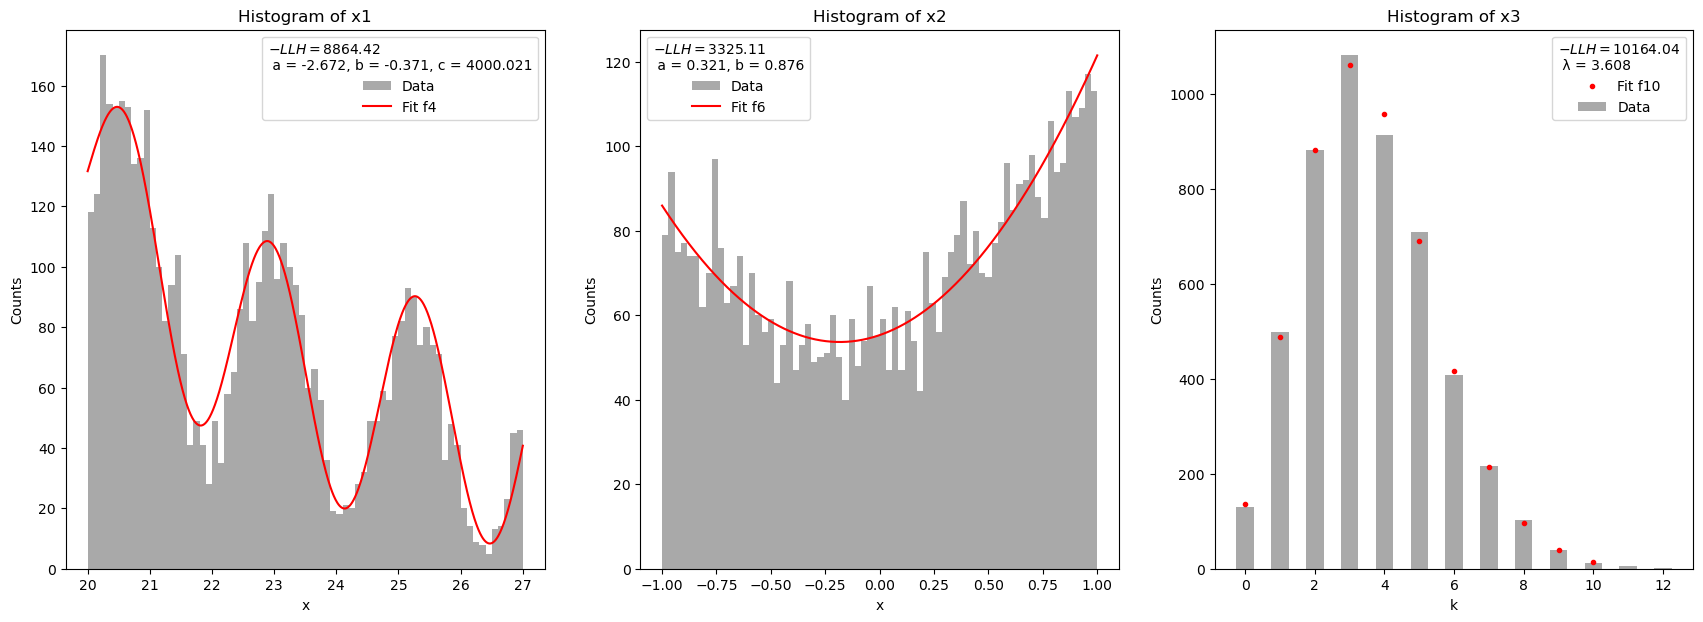

In [59]:
fig, ax = plt.subplots(1, 3, figsize=(21, 7))

xx1 = np.linspace(20, 27, 1000)
xmin1 = 20
xmax1 = 27
binwidth1 = (xmax1 - xmin1) / 70
ax[0].hist(x1, bins=70, range=(xmin1, xmax1), color='darkgray', label='Data')
ax[0].set_title(f'Histogram of x1')
ax[0].plot(xx1, f9_norm(xx1, *m1.values[:])*len(x1)*binwidth1, 'r-', label='Fit f4')
ax[0].legend(title=f"$-LLH = {m1.fval/2:.2f}$ \n a = {m1.values['a']:.3f}, b = {m1.values['b']:.3f}, c = {m1.values['c']:.3f}")
ax[0].set_xlabel('x')
ax[0].set_ylabel('Counts')

xx2 = np.linspace(-1, 1, 1000)
xmin2 = -1
xmax2 = 1
binwidth2 = (xmax2 - xmin2) / 70
ax[1].hist(x2, bins=70, range=(xmin2, xmax2), color='darkgray', label='Data')
ax[1].set_title(f'Histogram of x2')
ax[1].plot(xx2, f6_norm(xx2, *m2.values[:])*len(x2)*binwidth2, 'r-', label='Fit f6')
ax[1].legend(title=f"$-LLH = {m2.fval/2:.2f}$ \n a = {m2.values['a']:.3f}, b = {m2.values['b']:.3f}")
ax[1].set_xlabel('x')
ax[1].set_ylabel('Counts')

x3 = np.array(x3, dtype=int).flatten()
xx3 = np.arange(0, 11)
ax[2].bar(np.unique(x3), np.bincount(x3), width=0.5, color='darkgray', label='Data')
ax[2].set_title('Histogram of x3')
ax[2].plot(xx3, f11(xx3, m3.values['lamb'])*len(x3), 'r.', label='Fit f10')
ax[2].legend(title=f"$-LLH = {m3.fval/2:.2f}$ \n λ = {m3.values['lamb']:.3f}")
ax[2].set_xlabel('k')
ax[2].set_ylabel('Counts');